In [ ]:
import os
import sys
import ast
base_directory = os.path.dirname(os.path.abspath(""))
sys.path.append(base_directory)

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_histogram(df, xcol, xlabel=None, ylabel=None, title=None, logy=False, xmin=0, bins=20, output_path=None):
    num_na = df[xcol].isna().sum()
    print(f"Column '{xcol}' has {num_na} / {len(df)} null entries.")
    
    data = df[xcol].dropna()

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=bins, edgecolor='black')
    if xlabel is None:
        xlabel = xcol.replace("_", " ").title()
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if logy:
        plt.yscale('log')
    if xmin is not None:
        plt.xlim(xmin=xmin)
    if title:
        plt.title(title)
    plt.grid(axis='y', alpha=0.75)
    if output_path:
        plt.savefig(output_path)
    # plt.close()

def count_values_in_comma_joined_column(df, column_name):
    value_counts = Counter()
    for entry in df[column_name].dropna():
        for value in entry.split(","):
            value_counts[value.strip()] += 1
    labels = list(value_counts.keys())
    counts = list(value_counts.values())
    return labels, counts

def plot_bar_chart(categories, counts, xlabel, ylabel=None, title=None, output_path=None):
    plt.figure(figsize=(10, 6))
    plt.bar(categories, counts, edgecolor='black')
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    # plt.close()

In [ ]:
df_path = os.path.join(base_directory, "data", "radiology_db_sample_small.csv")  #!!! "output/radiology_db_notebook.csv"

if not os.path.exists(df_path):
    raise FileNotFoundError(f"Data file not found at {df_path}. Please ensure the file exists.")

df = pd.read_csv(df_path)

df_with_unverified = None
if "verified" in df.columns:
    df_with_unverified = df.copy()
    df = df[df["verified"] == True]

# Plot number of images, patients

Column 'num_images' has 28 / 112 null entries.
Column 'num_patients' has 28 / 112 null entries.


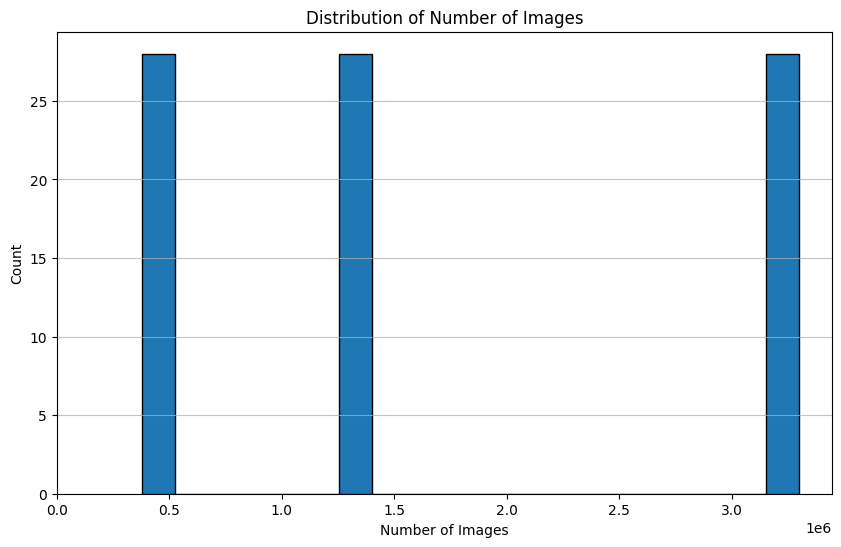

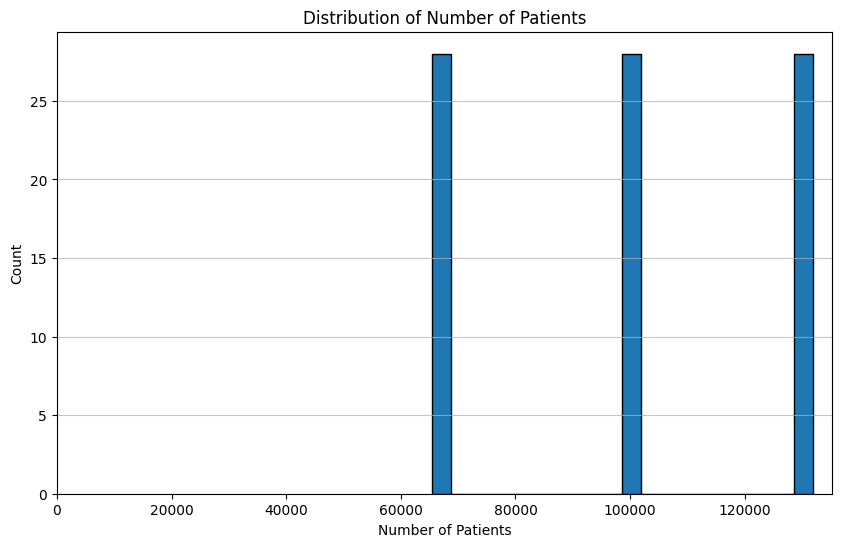

In [4]:
plot_histogram(df, "num_images", title="Distribution of Number of Images", xlabel="Number of Images", ylabel="Count")
plot_histogram(df, "num_patients", title="Distribution of Number of Patients", xlabel="Number of Patients", ylabel="Count")

Column 'images_per_patient' has 56 / 112 null entries.


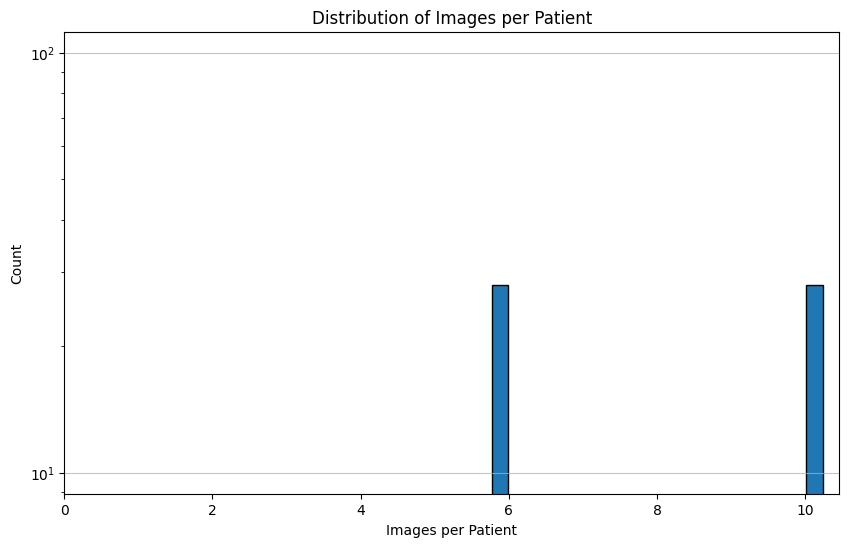

In [5]:
df["images_per_patient"] = df["num_images"] / df["num_patients"]
plot_histogram(df, "images_per_patient", title="Distribution of Images per Patient", xlabel="Images per Patient", ylabel="Count", logy=True)

# Modalities

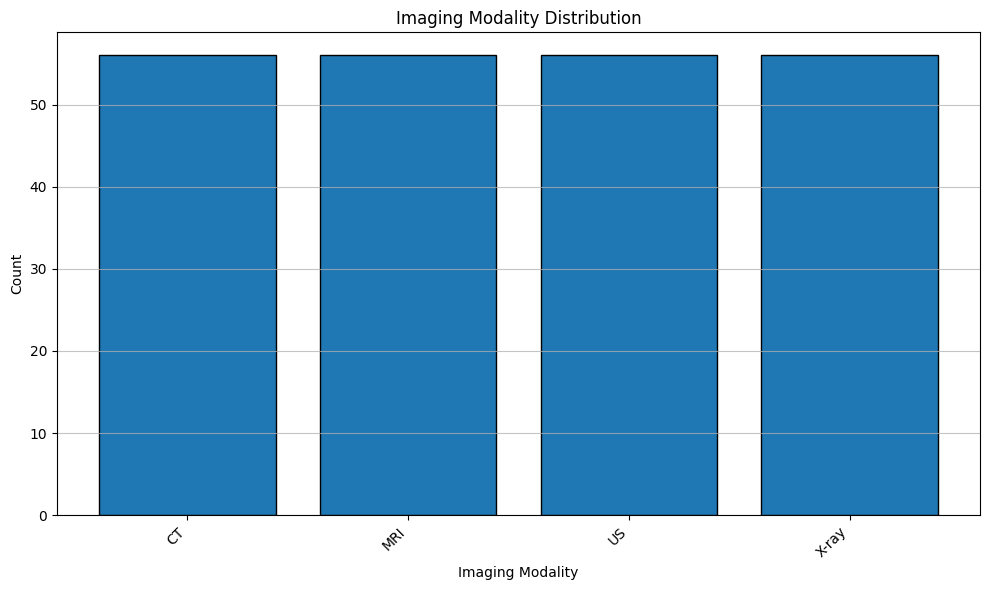

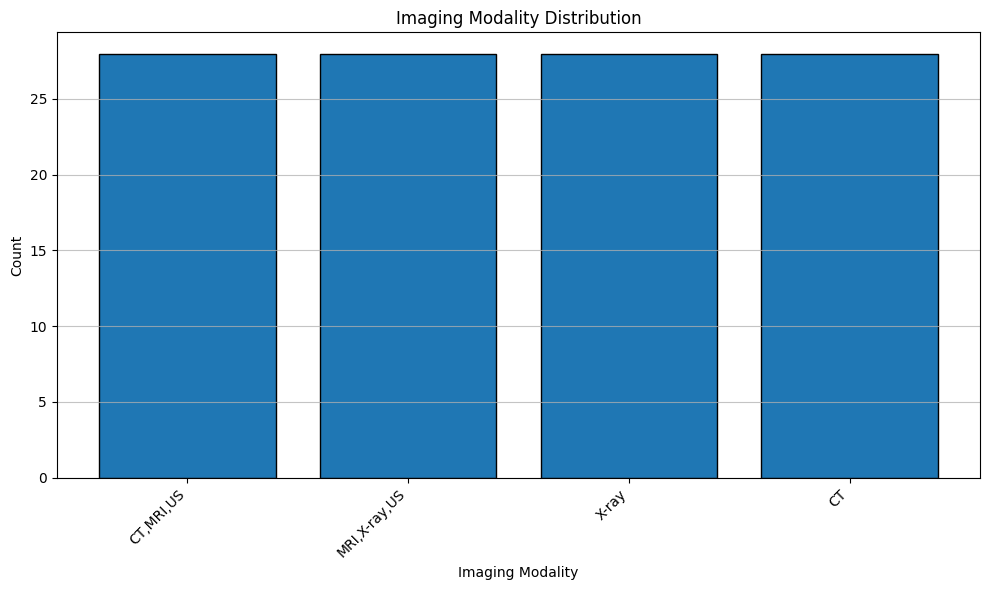

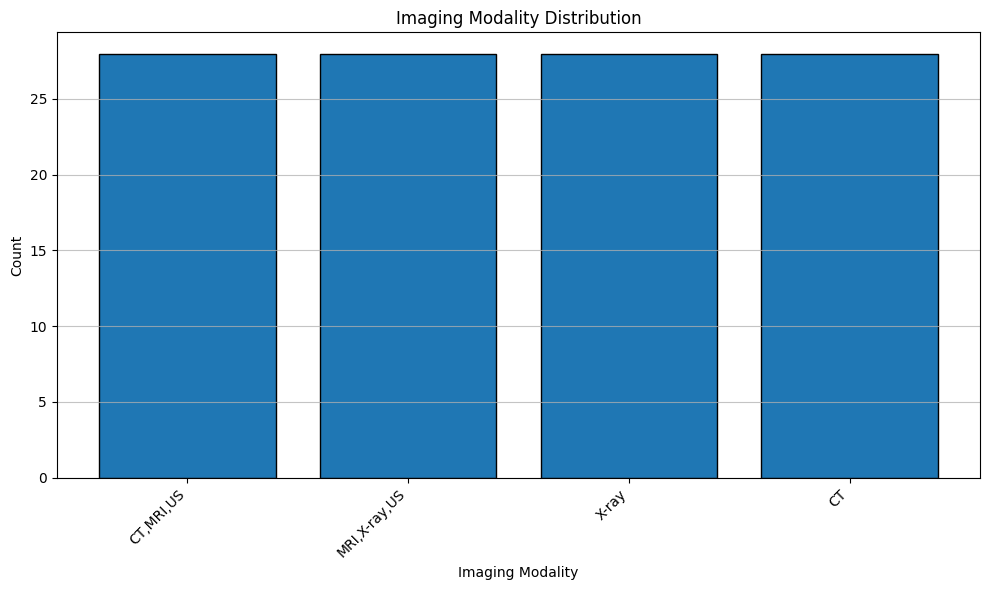

In [6]:
labels, values = count_values_in_comma_joined_column(df, "modalities")
plot_bar_chart(labels, values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].value_counts(dropna=False)
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

# Body regions

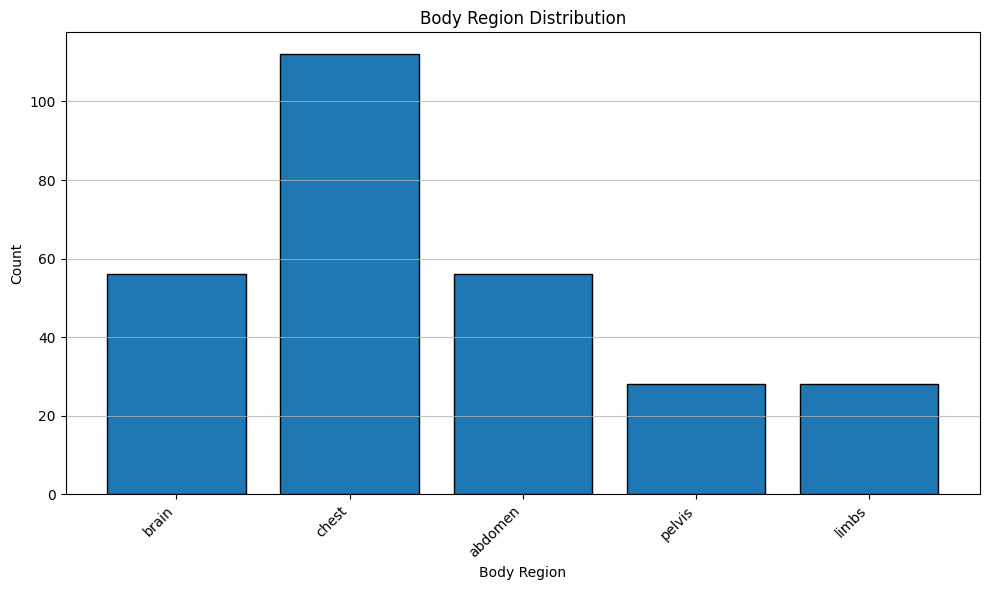

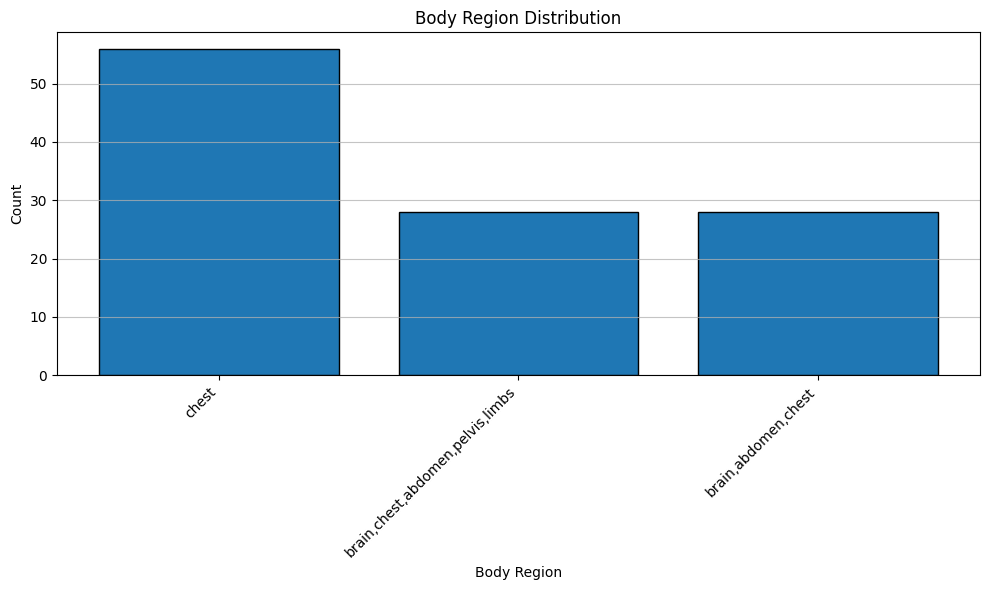

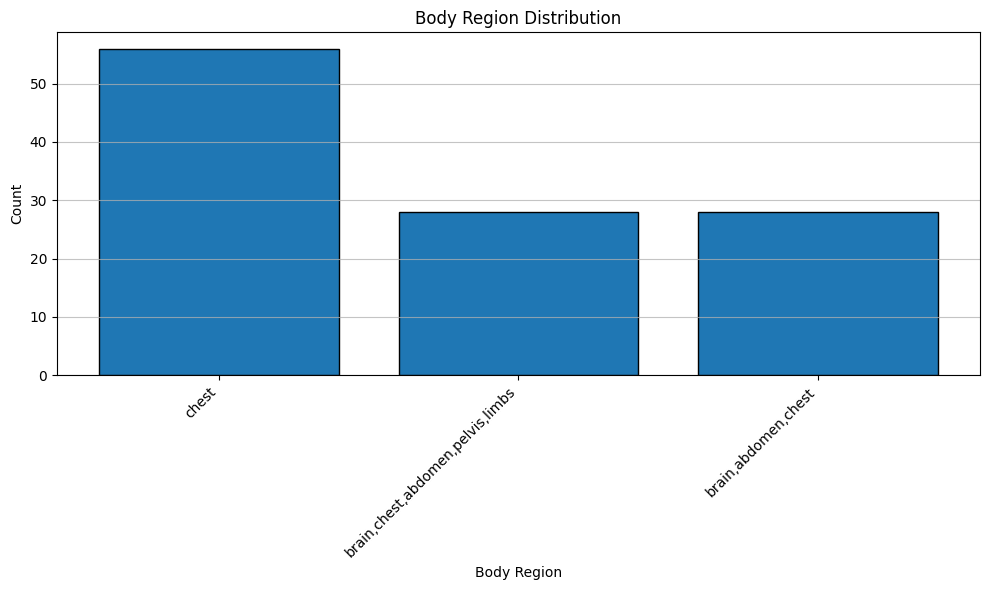

In [7]:
labels, values = count_values_in_comma_joined_column(df, "body_regions")
plot_bar_chart(labels, values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].value_counts(dropna=False)
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

# Additional data

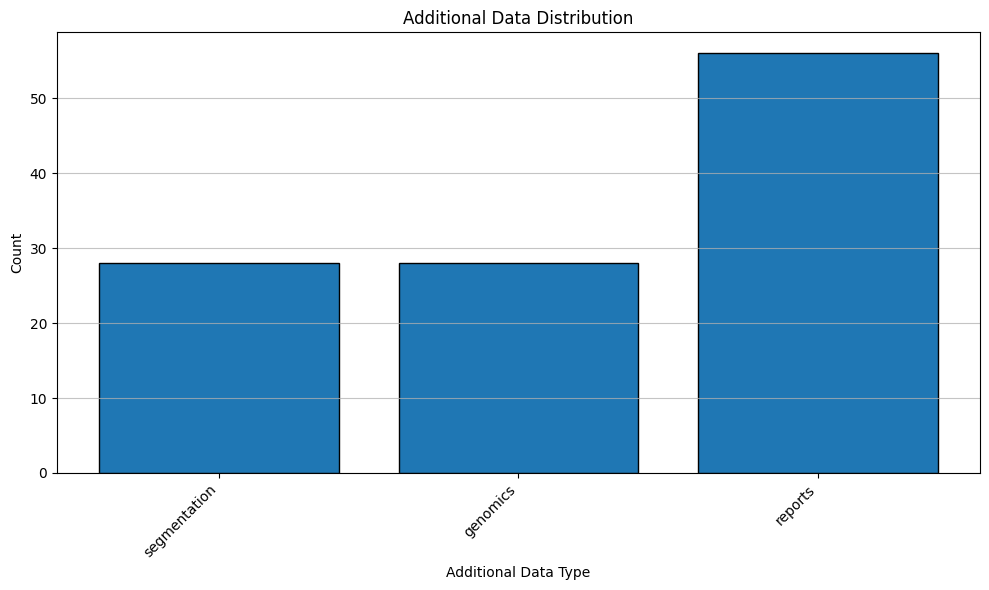

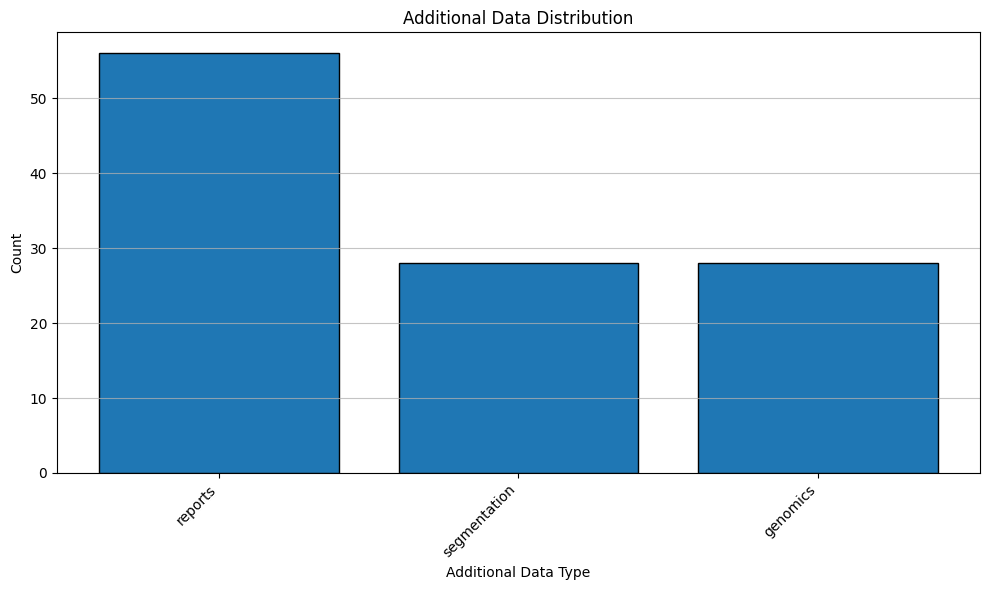

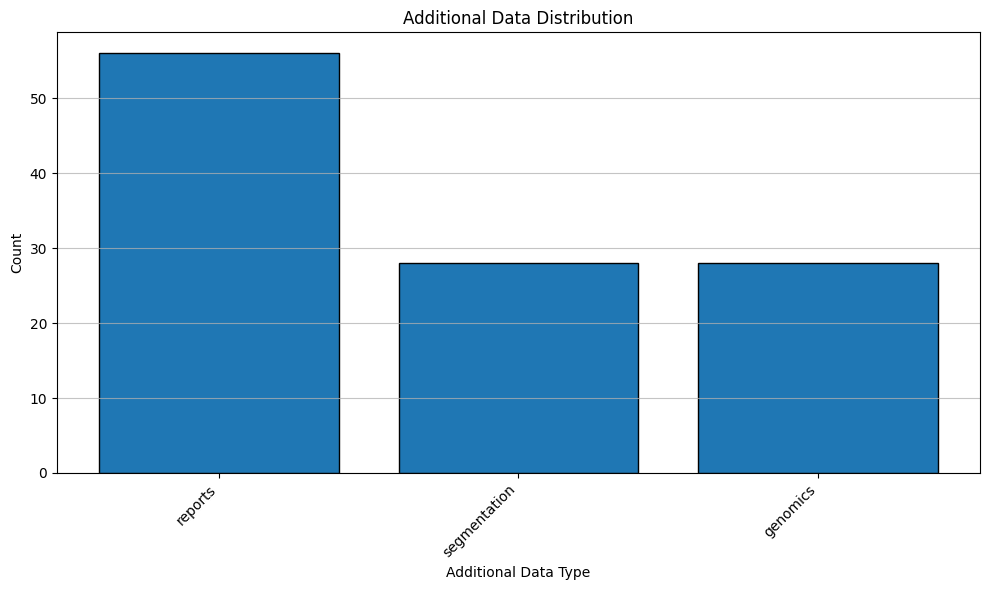

In [8]:
labels, values = count_values_in_comma_joined_column(df, "additional_data")
plot_bar_chart(labels, values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].value_counts(dropna=False)
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

## MeSH terms and PubMed query matches

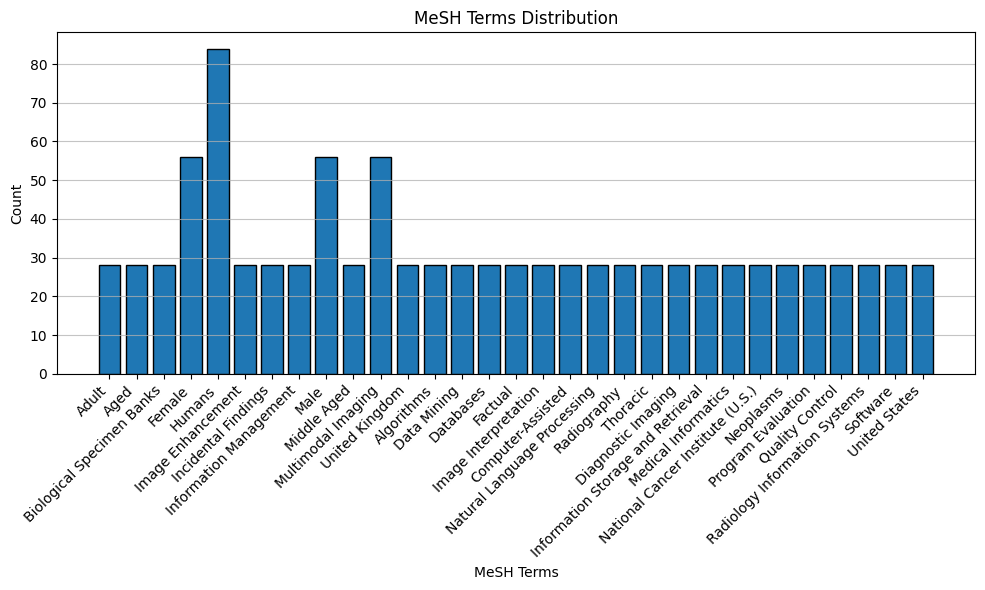

In [ ]:
labels, values = count_values_in_comma_joined_column(df, "mesh_terms_in_pubmed_matches")
plot_bar_chart(labels, values, xlabel="MeSH Terms", ylabel="Count", title="MeSH Terms Distribution")

In [13]:
df.head()

,name,num_images,num_patients,modalities,body_regions,additional_data,paper_title,paper_link,paper_year,paper_authors,paper_journal,pmid,paper_citation_count,mesh_terms,pubmed_matches,mesh_terms_in_pubmed_matches,mesh_terms_in_pubmed_matches_flattened,pubmed_matches_flattened
0,RadImageNet,1350000.0,131872.0,"CT,MRI,US","brain,chest,abdomen,pelvis,limbs",segmentation,RadImageNet: An Open Radiologic Deep Learning ...,https://doi.org/10.1148/ryai.210315,2022,"Mei X,Liu Z,Robson PM,Marinelli B,Huang M,Dosh...",Radiology. Artificial intelligence,36204533,156,NaN,"[['dataset[ti]'], ['""Medical Image""[tiab]', 'C...",[],,"[, [, ', d, a, t, a, s, e, t, [, t, i, ], ', ]..."
1,UK Biobank,NaN,100000.0,"MRI,X-ray,US","brain,abdomen,chest",genomics,"The UK Biobank imaging enhancement of 100,000 ...",https://doi.org/10.1038/s41467-020-15948-9,2020,"Littlejohns TJ,Holliday J,Gibson LM,Garratt S,...",Nature communications,32457287,535,"Adult,Aged,Biological Specimen Banks,Female,Hu...","[['""data collection""[ti]'], ['""X-ray""[tiab]', ...",[],,"[, [, ', "", d, a, t, a, , c, o, l, l, e, c, t..."
2,MIMIC-CXR,377110.0,65379.0,X-ray,chest,reports,"MIMIC-CXR, a de-identified publicly available ...",https://doi.org/10.1038/s41597-019-0322-0,2019,"Johnson AEW,Pollard TJ,Berkowitz SJ,Greenbaum ...",Scientific data,31831740,579,"Algorithms,Data Mining,Databases, Factual,Huma...","[['database[ti]'], ['radiology[tiab]']]",[],,"[, [, ', d, a, t, a, b, a, s, e, [, t, i, ], '..."
3,The Cancer Imaging Archive (TCIA),3300000.0,NaN,CT,chest,reports,The Cancer Imaging Archive (TCIA): maintaining...,https://doi.org/10.1007/s10278-013-9622-7,2013,"Clark K,Vendt B,Smith K,Freymann J,Kirby J,Kop...",Journal of digital imaging,23884657,2224,"Diagnostic Imaging,Female,Humans,Information S...","[['""information repository""[ti]'], ['""Radiolog...","[""Radiology Information Systems""[MeSH]]",""", R, a, d, i, o, l, o, g, y, , I, n, f, o, r...","[, [, ', "", i, n, f, o, r, m, a, t, i, o, n, ..."
4,RadImageNet,1350000.0,131872.0,"CT,MRI,US","brain,chest,abdomen,pelvis,limbs",segmentation,RadImageNet: An Open Radiologic Deep Learning ...,https://doi.org/10.1148/ryai.210315,2022,"Mei X,Liu Z,Robson PM,Marinelli B,Huang M,Dosh...",Radiology. Artificial intelligence,36204533,156,NaN,"[['dataset[ti]'], ['""Medical Image""[tiab]', 'C...",[],,"[, [, ', d, a, t, a, s, e, t, [, t, i, ], ', ]..."


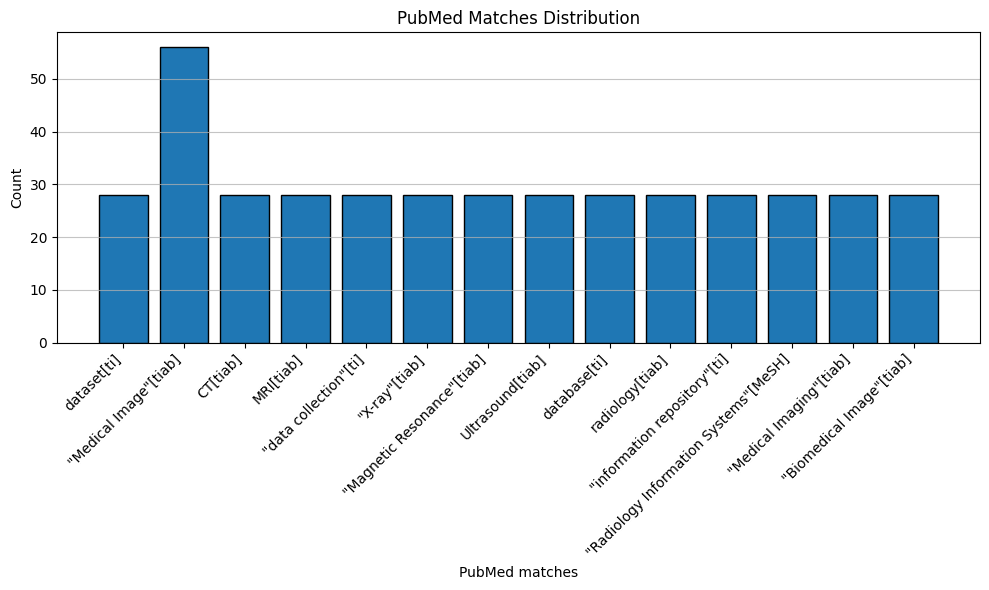

In [ ]:
def flatten_and_join(cell):
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except Exception:
            return ""

    if not isinstance(cell, (list, tuple)):
        return ""

    flat = []
    for sub in cell:
        if isinstance(sub, (list, tuple)):
            flat.extend(sub)
        elif isinstance(sub, str):
            flat.append(sub)

    return ", ".join(flat)


df["pubmed_matches_flattened"] = df["pubmed_matches"].apply(flatten_and_join)

labels, values = count_values_in_comma_joined_column(df, "pubmed_matches_flattened")
plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution")

### Compare with unverified data (if available)

In [ ]:
if df_with_unverified is not None:
    df_with_unverified["pubmed_matches_flattened"] = df_with_unverified["pubmed_matches"].apply(flatten_and_join)

    labels, values = count_values_in_comma_joined_column(df_with_unverified, "pubmed_matches_flattened")
    plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution")

# Citation counts

Column 'paper_year' has 0 / 112 null entries.


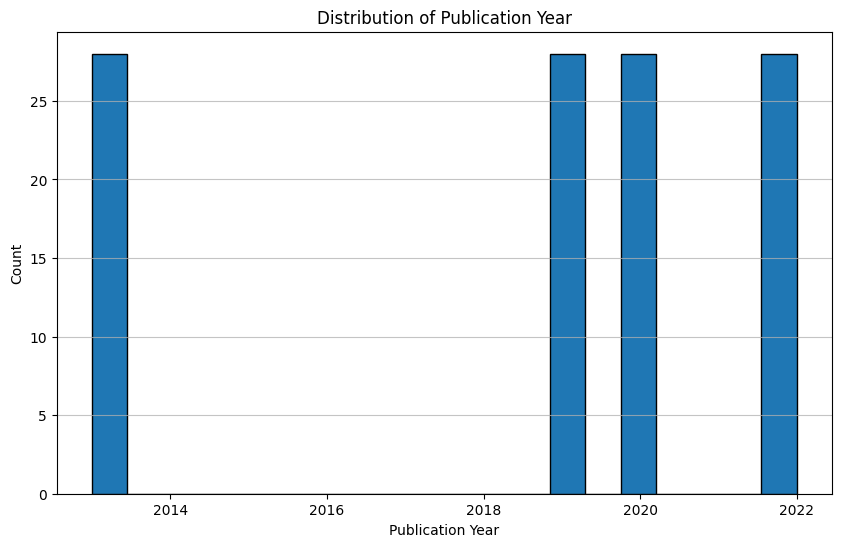

In [7]:
plot_histogram(df, "paper_year", title="Distribution of Publication Year", xlabel="Publication Year", ylabel="Count", xmin=None)

In [ ]:
!pip list

Package                                  Version         Build Editable project location
---------------------------------------- --------------- ----- -----------------------------------------------
accelerate                               1.13.0
ag-ui-protocol                           0.1.14
aiofile                                  3.9.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
anthropic                                0.86.0
anyio                                    4.12.1
apache-tvm-ffi                           0.1.9
argcomplete                              3.6.3
astor                                    0.8.1
asttokens                                3.0.1
async-timeout                            5.0.1
attrs                                    26.1.0
Authlib                                  1